# Beyond Price Prediction: DC-REIF for King County

A data-centric real estate intelligence workflow for valuation, submarket representation, uncertainty-aware pricing anomaly detection, and explainable outputs on the King County house sales dataset.


## 1. Project Overview

**DC-REIF** is designed as a student-scale, reproducible, trust-aware analytics system. The framework emphasizes governance, leakage-safe modeling, market-context segmentation, out-of-fold fair value estimation, and pricing anomaly detection on realized sale prices.


## 2. Business Understanding

This dataset contains **sale prices**, not asking prices. That means the downstream signal is framed as **Pricing Anomaly Detection** or **Valuation Gap Analysis** rather than strict asking-price mispricing detection.

Methodological safeguards used here:

- No target-derived features in the predictive path.
- Preprocessing is fit on training data or training folds only.
- Out-of-fold fair values are used for anomaly analysis.
- Submarket clustering uses ex-ante observable property and location characteristics only.


## 3. Colab / Environment Setup

This bootstrap cell works in local Jupyter and Google Colab. In Colab it can mount Drive, install requirements, resolve paths, and make the package importable from the repository source tree.


In [1]:
from pathlib import Path
import os
import sys
import subprocess

CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path('/content/dc-reif'),
    Path('/content'),
]
PROJECT_ROOT = next((candidate.resolve() for candidate in CANDIDATES if (candidate / 'src' / 'dc_reif').exists()), Path.cwd().resolve())
SRC_ROOT = PROJECT_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(PROJECT_ROOT / 'requirements.txt')], check=False)

from dc_reif.environment import is_running_in_colab, maybe_mount_drive, resolve_data_path, resolve_output_root
from dc_reif.config import ProjectConfig

if is_running_in_colab():
    maybe_mount_drive(force=False)

os.environ.setdefault('OUTPUT_DIR', str((PROJECT_ROOT / 'outputs').resolve()))
config = ProjectConfig.default()
config.paths.ensure()

print({'project_root': str(PROJECT_ROOT), 'data_dir': str(config.data_dir), 'outputs_dir': str(config.paths.outputs_dir), 'in_colab': is_running_in_colab()})


{'project_root': 'C:\\Users\\Admin\\OneDrive\\Desktop\\New folder (4)', 'data_dir': 'C:\\Users\\Admin\\OneDrive\\Desktop\\New folder (4)\\data\\raw', 'outputs_dir': 'C:\\Users\\Admin\\OneDrive\\Desktop\\New folder (4)\\outputs', 'in_colab': False}


## 4. Data Download and Integrity

The downloader prefers `aria2c` when available, falls back to `requests` / `urllib`, supports configurable URLs, and verifies SHA-256 for the default public mirror.


In [2]:
import pandas as pd

from dc_reif.data_download import download_dataset
from dc_reif.data_ingestion import load_raw_data

dataset_path = download_dataset(config)
raw_df, manifest = load_raw_data(dataset_path, config.manifest_path)
pd.DataFrame([manifest])


2026-04-24 03:57:54,565 | INFO | dc_reif.data_download | Resolved data directory: C:\Users\Admin\OneDrive\Desktop\New folder (4)\data\raw


2026-04-24 03:57:54,566 | INFO | dc_reif.data_download | Resolved dataset path: C:\Users\Admin\OneDrive\Desktop\New folder (4)\data\raw\kc_house_data.csv


2026-04-24 03:57:54,567 | INFO | dc_reif.data_download | Configured DATA_URL: https://raw.githubusercontent.com/randellmwania/Kings-County-Housing-Project/master/data/kc_house_data.csv


2026-04-24 03:57:54,570 | INFO | dc_reif.data_download | Existing file checksum matched. Reusing C:\Users\Admin\OneDrive\Desktop\New folder (4)\data\raw\kc_house_data.csv


2026-04-24 03:57:54,620 | INFO | dc_reif.data_ingestion | Raw data manifest written to C:\Users\Admin\OneDrive\Desktop\New folder (4)\data\artifacts\raw_data_manifest.json


,filename,path,file_size_bytes,timestamp_utc,checksum_sha256
0,kc_house_data.csv,C:\Users\Admin\OneDrive\Desktop\New folder (4)...,2815526,2026-04-23T20:57:54.617608+00:00,970a5ee2b0294257cdb18952813df2dd05974f923a9a07...


## 5. Schema Audit and Data Quality

We validate required columns, summarize missingness, inspect invalid values, and produce a data-quality report before any modeling work.


In [3]:
from dc_reif.data_validation import validate_schema, validation_report_frame, summarize_missingness

validation_report = validate_schema(raw_df, config.required_columns)
validation_summary = validation_report_frame(validation_report)
missingness = summarize_missingness(raw_df)

print('Missing required columns:', validation_report.missing_columns)
validation_summary.head(15)


Missing required columns: []


,metric,value,section
0,row_count,21597,overview
1,column_count,21,overview
2,duplicate_rows,0,overview
3,missing_required_columns,0,overview
4,yr_renovated,3842,missing
5,waterfront,2376,missing
6,view,63,missing
7,date,0,missing
8,id,0,missing
9,bathrooms,0,missing


In [4]:
missingness.head(10)


,column,missing_pct
15,yr_renovated,17.79
8,waterfront,11.00
9,view,0.29
1,date,0.00
0,id,0.00
4,bathrooms,0.00
3,bedrooms,0.00
2,price,0.00
6,sqft_lot,0.00
7,floors,0.00


## 6. Data Cleaning

Cleaning is deterministic and follows a **flag-first, drop-later** policy. Clearly impossible rows are removed, while valid market extremes are retained and flagged.


In [5]:
from dc_reif.data_cleaning import clean_king_county_data

cleaning_result = clean_king_county_data(raw_df)
clean_df = cleaning_result.dataframe
cleaning_result.summary


{'rows_in': 21597,
 'rows_after_deduplication': 21597,
 'duplicates_removed': 0,
 'rows_dropped_invalid': 0,
 'rows_flagged_suspect': 1332,
 'rows_out': 21597}

## 7. Feature Engineering

Temporal, age, renovation, structural, and spatial signals are assembled while keeping descriptive-only variables such as `price_per_sqft` out of the predictive branch.


In [6]:
from dc_reif.feature_engineering import build_feature_matrix, assert_no_target_leakage

feature_set = build_feature_matrix(clean_df, include_enhanced_features=True)
modeling_df = feature_set.dataframe.sort_values([config.date_column, config.id_column]).reset_index(drop=True)
predictive_features = feature_set.predictive_features.copy()
assert_no_target_leakage(predictive_features)

print('Predictive features:', predictive_features)
print('Descriptive-only features:', feature_set.descriptive_features)
modeling_df[['id', 'date', 'price', 'price_per_sqft', 'sale_year', 'house_age']].head()


Predictive features: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month', 'sale_quarter', 'house_age', 'renovated_flag', 'years_since_renovation', 'total_sqft', 'living_to_lot_ratio', 'basement_share', 'bathrooms_per_bedroom', 'sqft_per_floor', 'relative_living_area', 'relative_lot_size', 'sale_month_sin', 'sale_month_cos', 'build_decade', 'renovation_recency', 'lat_bin', 'long_bin', 'geo_cell', 'distance_to_seattle_core', 'distance_to_bellevue_core', 'grade_living_interaction', 'waterfront_view_score', 'location_grade_interaction']
Descriptive-only features: ['price_per_sqft']


,id,date,price,price_per_sqft,sale_year,house_age
0,123059127,2014-05-02,625000.0,228.937729,2014,7
1,472000620,2014-05-02,790000.0,303.846154,2014,63
2,587550340,2014-05-02,604000.0,186.419753,2014,19
3,776600130,2014-05-02,275000.0,233.050847,2014,31
4,943100683,2014-05-02,335000.0,212.025316,2014,36


## 8. Exploratory Data Analysis

The EDA is descriptive only. `price_per_sqft` may appear here for interpretation, but it is excluded from predictive modeling.


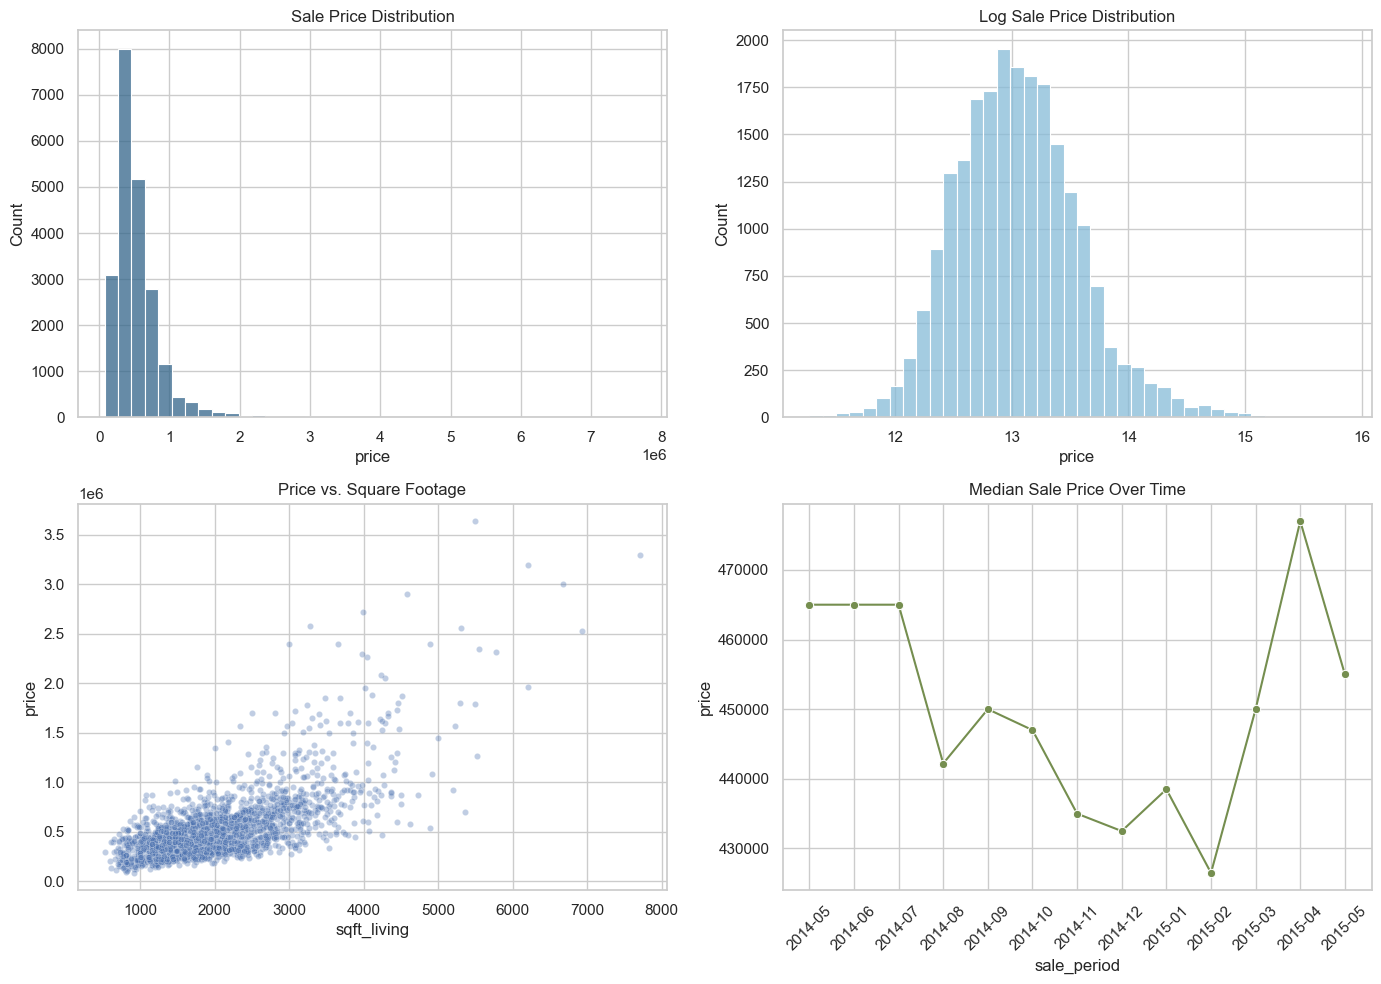

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(modeling_df['price'], bins=40, ax=axes[0, 0], color='#33658a')
axes[0, 0].set_title('Sale Price Distribution')

sns.histplot(np.log(modeling_df.loc[modeling_df['price'] > 0, 'price']), bins=40, ax=axes[0, 1], color='#86bbd8')
axes[0, 1].set_title('Log Sale Price Distribution')

sns.scatterplot(data=modeling_df.sample(min(len(modeling_df), 2000), random_state=42), x='sqft_living', y='price', ax=axes[1, 0], alpha=0.35, s=20)
axes[1, 0].set_title('Price vs. Square Footage')

monthly_trend = modeling_df.assign(sale_period=modeling_df['date'].dt.to_period('M').astype(str)).groupby('sale_period')['price'].median().reset_index()
sns.lineplot(data=monthly_trend, x='sale_period', y='price', marker='o', ax=axes[1, 1], color='#758e4f')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_title('Median Sale Price Over Time')

plt.tight_layout()
plt.show()


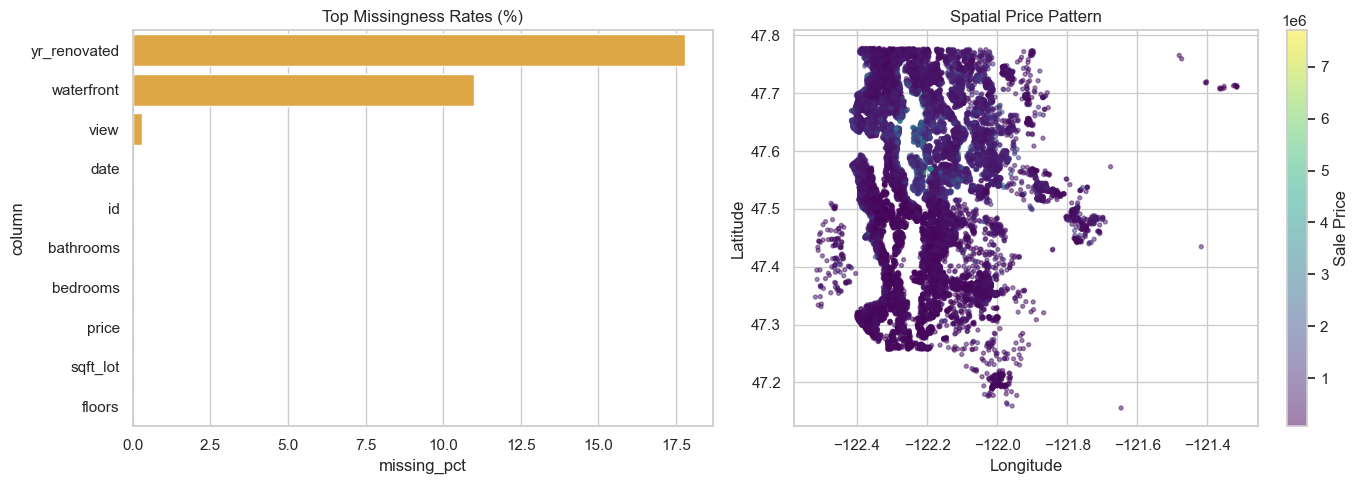

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
missingness_plot = missingness.head(10)
sns.barplot(data=missingness_plot, x='missing_pct', y='column', ax=axes[0], color='#f6ae2d')
axes[0].set_title('Top Missingness Rates (%)')

scatter = axes[1].scatter(modeling_df['long'], modeling_df['lat'], c=modeling_df['price'], cmap='viridis', s=8, alpha=0.5)
fig.colorbar(scatter, ax=axes[1], label='Sale Price')
axes[1].set_title('Spatial Price Pattern')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()


## 9. Train/Validation/Test Design

Splits are chronological to respect the temporal structure of transactions and reduce leakage risk.


In [9]:
from dc_reif.splitting import chronological_split

split = chronological_split(modeling_df)
summary = pd.DataFrame([
    {'split': 'train', 'rows': len(split.train_df), 'start': split.train_df['date'].min(), 'end': split.train_df['date'].max()},
    {'split': 'validation', 'rows': len(split.validation_df), 'start': split.validation_df['date'].min(), 'end': split.validation_df['date'].max()},
    {'split': 'test', 'rows': len(split.test_df), 'start': split.test_df['date'].min(), 'end': split.test_df['date'].max()},
])
summary


,split,rows,start,end
0,train,15117,2014-05-02,2015-01-16
1,validation,3239,2015-01-16,2015-03-26
2,test,3241,2015-03-26,2015-05-27


## 10. Valuation Core

The final validated workflow uses one official valuation path with enhanced dataset-aligned market-context features and leakage-safe preprocessing.

## 11. Official Valuation Model

XGBoost is the single official valuation model for this repository. The notebook reports its validation and holdout performance without presenting multiple public-facing model tracks.

## 12. Out-of-Fold Fair Value

Fair values for the anomaly workflow must be out-of-fold for training-era records and honest forward predictions for the final holdout set.


## 13. Submarket Representation with KMeans

KMeans is used as a market-context encoding layer, not as the project?s standalone end goal.


In [10]:
from dc_reif.clustering import fit_submarket_clustering, assign_submarket_segments
from dc_reif.valuation import train_and_select_model

cluster_artifacts = fit_submarket_clustering(
    split.train_df,
    random_state=config.random_state,
    include_enhanced_features=True,
)
modeling_df['segment_label'] = assign_submarket_segments(modeling_df, cluster_artifacts)
predictive_features = feature_set.predictive_features + ['segment_label']
assert_no_target_leakage(predictive_features)

split = chronological_split(modeling_df)
valuation = train_and_select_model(
    train_df=split.train_df,
    validation_df=split.validation_df,
    train_validation_df=split.train_validation_df,
    test_df=split.test_df,
    feature_columns=predictive_features,
    target_column=config.target_column,
    n_splits=config.n_splits,
    random_state=config.random_state,
)

print('Selected model:', valuation.model_name)
pd.DataFrame([{'selected_model': valuation.model_name, **valuation.evaluation_summary[valuation.model_name]}])


Selected model: xgboost


,selected_model,validation_rmse,validation_mae,validation_mape,validation_r2,test_rmse,test_mae,test_mape,test_r2
0,xgboost,110852.906508,65525.936801,12.933957,0.8963,121629.657923,70271.434578,12.437626,0.895698


In [11]:
cluster_artifacts.cluster_profiles


,segment_label,sqft_living,grade,condition,house_age,lat,long,count
5,segment_5,1290.0,7.0,3.0,64.0,47.62170,-122.301,3789
1,segment_1,2880.0,9.0,3.0,16.0,47.61760,-122.118,3461
0,segment_0,1860.0,7.0,3.0,28.0,47.35570,-122.169,3121
3,segment_3,2210.0,7.0,4.0,56.0,47.63250,-122.291,3059
2,segment_2,1480.0,8.0,3.0,8.0,47.63355,-122.340,1138
4,segment_4,2240.0,8.0,3.0,73.0,47.60590,-122.292,549


## 14. Uncertainty Estimation

A practical conformal-style interval is estimated from out-of-fold residuals.


In [12]:
from dc_reif.uncertainty import conformal_quantile, build_prediction_intervals, evaluate_interval_quality

fair_value_hat = pd.Series(np.nan, index=modeling_df.index, name='fair_value_hat')
fair_value_hat.loc[valuation.fair_value_hat_oof.index] = valuation.fair_value_hat_oof
fair_value_hat.loc[valuation.fair_value_hat_test.index] = valuation.fair_value_hat_test

oof_mask = valuation.fair_value_hat_oof.notna()
residuals = split.train_validation_df.loc[oof_mask, config.target_column] - valuation.fair_value_hat_oof.loc[oof_mask]
q_hat = conformal_quantile(residuals, alpha=config.alpha)
intervals = build_prediction_intervals(fair_value_hat, q_hat=q_hat)
interval_metrics = evaluate_interval_quality(
    split.test_df[config.target_column],
    intervals.loc[split.test_df.index, 'lower_bound'],
    intervals.loc[split.test_df.index, 'upper_bound'],
)

print({'q_hat': q_hat, **interval_metrics})


{'q_hat': 140469.125, 'empirical_coverage': 0.8830607837087319, 'average_interval_width': 280938.25}


## 15. Pricing Anomaly Detection

Observed sale prices are compared with fair value intervals to derive valuation gaps and anomaly flags.


In [13]:
from dc_reif.anomaly import compute_pricing_anomalies

property_frame = pd.DataFrame({
    'property_id': modeling_df['id'].astype(str),
    'observed_price': modeling_df['price'],
    'fair_value_hat': intervals['fair_value_hat'],
    'lower_bound': intervals['lower_bound'],
    'upper_bound': intervals['upper_bound'],
    'interval_width': intervals['interval_width'],
    'segment_label': modeling_df['segment_label'],
    'data_quality_flag': modeling_df['data_quality_flag'],
})
property_frame = compute_pricing_anomalies(property_frame)
property_frame['anomaly_flag'].value_counts()


anomaly_flag
within_expected_range       16630
insufficient_history         3061
potentially_over_valued      1125
potentially_under_valued      781
Name: count, dtype: int64

## 16. Explainability

The final section below generates global feature importance and, when SHAP is available, a summary plot plus local drivers for a small sample of properties.


In [14]:
from dc_reif.explainability import global_feature_importance, plot_feature_importance, shap_explanations, build_top_driver_map

importance_df = global_feature_importance(valuation.model_pipeline, valuation.model_name)
plot_feature_importance(importance_df, config.paths.figures_dir / 'notebook_feature_importance.png')

explain_sample = (
    property_frame.loc[property_frame['anomaly_flag'] != 'insufficient_history']
    .assign(abs_score=lambda frame: frame['anomaly_score'].abs())
    .sort_values('abs_score', ascending=False)
    .head(3)
)
_, local_driver_map = shap_explanations(
    valuation.model_pipeline,
    dataset=modeling_df,
    feature_columns=predictive_features,
    output_path=config.paths.figures_dir / 'notebook_shap_summary.png',
    local_sample_ids=explain_sample['property_id'].tolist(),
    id_column=config.id_column,
)
property_frame['top_drivers'] = build_top_driver_map(
    modeling_df,
    id_column=config.id_column,
    importance_df=importance_df,
    local_driver_map=local_driver_map,
)
importance_df.head(15)


,feature,importance
0,grade_living_interaction,0.172071
1,location_grade_interaction,0.168105
2,waterfront,0.039525
3,distance_to_seattle_core,0.035827
4,waterfront_view_score,0.034488
5,sqft_living,0.017297
6,view,0.015080
7,lat,0.014458
8,renovated_flag,0.013673
9,distance_to_bellevue_core,0.013470


## 17. Final Property Intelligence Output

This table combines governance flags, fair value estimates, intervals, segment context, anomaly labels, and explanation text.


In [15]:
final_columns = [
    'property_id',
    'observed_price',
    'fair_value_hat',
    'lower_bound',
    'upper_bound',
    'segment_label',
    'anomaly_flag',
    'anomaly_score',
    'top_drivers',
    'data_quality_flag',
]
property_frame[final_columns].head(10)


,property_id,observed_price,fair_value_hat,lower_bound,upper_bound,segment_label,anomaly_flag,anomaly_score,top_drivers,data_quality_flag
0,123059127,625000.0,NaN,NaN,NaN,segment_1,insufficient_history,NaN,"grade_living_interaction, location_grade_inter...",ok
1,472000620,790000.0,NaN,NaN,NaN,segment_3,insufficient_history,NaN,"grade_living_interaction, location_grade_inter...",ok
2,587550340,604000.0,NaN,NaN,NaN,segment_0,insufficient_history,NaN,"grade_living_interaction, location_grade_inter...",ok
3,776600130,275000.0,NaN,NaN,NaN,segment_0,insufficient_history,NaN,"grade_living_interaction, location_grade_inter...",ok
4,943100683,335000.0,NaN,NaN,NaN,segment_0,insufficient_history,NaN,"grade_living_interaction, location_grade_inter...",ok
5,1024069009,675000.0,NaN,NaN,NaN,segment_1,insufficient_history,NaN,"grade_living_interaction, location_grade_inter...",ok
6,1088800850,612500.0,NaN,NaN,NaN,segment_1,insufficient_history,NaN,"grade_living_interaction, location_grade_inter...",ok
7,1245003160,698000.0,NaN,NaN,NaN,segment_3,insufficient_history,NaN,"grade_living_interaction, location_grade_inter...",ok
8,1323089184,452500.0,NaN,NaN,NaN,segment_0,insufficient_history,NaN,"grade_living_interaction, location_grade_inter...",ok
9,1525079056,284000.0,NaN,NaN,NaN,segment_0,insufficient_history,NaN,"grade_living_interaction, location_grade_inter...",ok


## 18. Report-Ready Results Summary

This section loads the canonical frozen results summary used across the report, slide deck, notebook, and GitHub documentation. If the summary file is missing, run `python scripts/build_report_results.py` first.


In [16]:
from pathlib import Path
import json
import pandas as pd

results_path = PROJECT_ROOT / 'outputs' / 'reports' / 'final_results_master.json'
if not results_path.exists():
    raise FileNotFoundError(
        f'Missing {results_path}. Run `python scripts/build_report_results.py` to generate the report-ready summary.'
    )

final_results_master = json.loads(results_path.read_text(encoding='utf-8'))
results_summary_table = pd.DataFrame([
    {'section': 'valuation', 'metric': 'selected_model', 'value': final_results_master['core_valuation_metrics']['selected_model']},
    {'section': 'valuation', 'metric': 'validation_rmse', 'value': final_results_master['core_valuation_metrics']['validation_rmse']},
    {'section': 'valuation', 'metric': 'test_rmse', 'value': final_results_master['core_valuation_metrics']['test_rmse']},
    {'section': 'valuation', 'metric': 'validation_mae', 'value': final_results_master['core_valuation_metrics']['validation_mae']},
    {'section': 'valuation', 'metric': 'test_mae', 'value': final_results_master['core_valuation_metrics']['test_mae']},
    {'section': 'valuation', 'metric': 'validation_r2', 'value': final_results_master['core_valuation_metrics']['validation_r2']},
    {'section': 'valuation', 'metric': 'test_r2', 'value': final_results_master['core_valuation_metrics']['test_r2']},
    {'section': 'segmentation', 'metric': 'segment_count', 'value': final_results_master['segmentation_results']['segment_count']},
    {'section': 'uncertainty', 'metric': 'interval_coverage', 'value': final_results_master['uncertainty_results']['interval_coverage']},
    {'section': 'uncertainty', 'metric': 'conformal_qhat', 'value': final_results_master['uncertainty_results']['conformal_qhat']},
    {'section': 'anomaly', 'metric': 'within_expected_range', 'value': final_results_master['pricing_anomaly_results']['within_expected_range']},
    {'section': 'anomaly', 'metric': 'potentially_over_valued', 'value': final_results_master['pricing_anomaly_results']['potentially_over_valued']},
    {'section': 'anomaly', 'metric': 'potentially_under_valued', 'value': final_results_master['pricing_anomaly_results']['potentially_under_valued']},
    {'section': 'anomaly', 'metric': 'insufficient_history', 'value': final_results_master['pricing_anomaly_results']['insufficient_history']},
])
results_summary_table


,section,metric,value
0,valuation,selected_model,xgboost
1,valuation,validation_rmse,110852.91
2,valuation,test_rmse,121629.66
3,valuation,validation_mae,65525.94
4,valuation,test_mae,70271.43
5,valuation,validation_r2,0.8963
6,valuation,test_r2,0.8957
7,segmentation,segment_count,6
8,uncertainty,interval_coverage,0.8831
9,uncertainty,conformal_qhat,140469.12


## 19. Limitations and Future Work

- The system analyzes realized sale prices, so anomaly labels are valuation-gap signals rather than strict asking-price mispricing claims.
- Public mirrors of this dataset may encode some fields differently; the governance layer standardizes both numeric and text variants.
- Prediction intervals here are practical and lightweight rather than fully heteroscedastic.
- Future work could strengthen spatial feature engineering, richer uncertainty calibration, and segment-specific diagnostics without turning this into a model-zoo project.
